# Combining Pessimism and Physical viability in the RL reward


## Abstract

This notebook combines the two reward terms built in notebooks 09 and 10 into a single REINVENT run. The first is the pessimistic multifitness of notebook 09: the notebook-07 composite fitness (activity, QED, applicability domain, synthetic accessibility, with PAINS/Brenk and property guards), where the raw activity estimate is replaced by the lower confidence bound μ − λσ (λ = 2). The second is the xTB viability guardrail of notebook 10. The two are joined by a geometric mean. The run is compared to the optimistic multifitness baseline. Neither term reshapes the generated distribution. The xTB viability stays near 0.97 from the first step, and pessimism does not lower uncertainty: the median σ is 0.231 against 0.221 for the baseline. The result motivates the systematic leave-one-out ablation.

## Introduction

Notebook 09 introduced a pessimistic activity term and notebook 10 an xTB viability term. Here they are combined for the first time in one reward. The question is direct: does adding them change what the agent generates?

## Methods

The reward is the geometric mean of two components, each implemented as a REINVENT scoring plugin. MultiFitnessPess is the notebook-07 multifitness, that is activity × QED × applicability domain × synthetic accessibility gated by the structural guards, with the point-estimate activity replaced by the pessimistic lower confidence bound μ − λσ (λ = 2). XtbViability is the stability surrogate of notebook 10, mapped to 1 − P(unstable). The agent follows the notebook-08 setup (190 steps, batch 64). The run is compared to the optimistic multifitness baseline on reward-independent quantities: the ensemble uncertainty σ and the predicted activity μ of the final population (last 25% of steps).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, glob, os
import joblib
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, QED

from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

plt.rcParams["figure.dpi"] = 80     
plt.rcParams["font.size"] = 9       
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 8

REPO = "/mnt/c/Users/coure/Projects/cheminformatics"
RUNDIR = f"{REPO}/rl_runs"

ens = joblib.load(f"{REPO}/models/egfr_ensemble.joblib")

BATCH = 64

df = pd.read_csv(f"{RUNDIR}/egfr_xtb_pess_1.csv")
print(df.shape)
print(list(df.columns))
df.head()

(12160, 11)
['Agent', 'Prior', 'Target', 'Score', 'SMILES', 'SMILES_state', 'multifitness pessimistic (lambda=2)', 'multifitness pessimistic (lambda=2) (raw)', 'xTB viability', 'xTB viability (raw)', 'step']


,Agent,Prior,Target,Score,SMILES,SMILES_state,multifitness pessimistic (lambda=2),multifitness pessimistic (lambda=2) (raw),xTB viability,xTB viability (raw),step
0,31.6066,31.6066,0.2439,0.248833,C1=NOCC12CCC1(CCC1)C2,1,0.062538,0.0625,0.990076,0.9901,1
1,30.9630,30.9630,37.5156,0.534989,CCNC(=O)c1ccc(NC(=O)c2ccc(O)c(Cl)c2)cc1Cl,1,0.291093,0.2911,0.983237,0.9832,1
2,26.7286,26.7286,32.6514,0.463907,COc1cc(OC)c(C2CCCCC2N)cc1Cl,1,0.217104,0.2171,0.991273,0.9913,1
3,27.4110,27.4110,49.0761,0.597556,O=C(CN1CCN(C(=O)c2cn(-c3ccccc3)nn2)CC1)N1CCCC1,1,0.376118,0.3761,0.949364,0.9494,1
4,30.9530,30.9530,-30.9404,0.000098,COCCNC(=O)C1CN(Cc2c(F)cccc2Cl)CC1C,1,0.000000,0.0000,0.965681,0.9657,1


## Results

Over 190 steps the total score and the pessimistic multifitness rise, then plateau. Early in training many generated molecules are rejected by the structural guards and score zero; by the end almost none remain. The xTB viability term behaves differently: it stays above 0.9 at every step and never leaves the ceiling.

The reward-independent comparison isolates the effect of pessimism. For the final population of each run (last 25% of steps), the ensemble uncertainty σ and the predicted activity μ were recomputed with the same ten-model ensemble. The pessimistic and optimistic runs are indistinguishable. The median σ is 0.231 for the pessimistic run and 0.221 for the optimistic baseline. The median μ is 5.63 and 5.53. The pessimistic distribution is not shifted toward lower uncertainty.

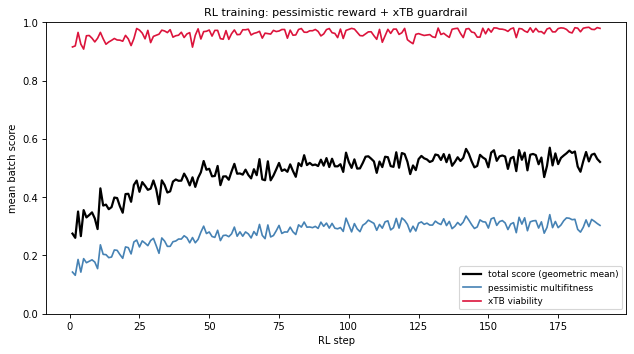

In [2]:
score_col = "Score" if "Score" in df.columns else [c for c in df.columns if c.lower()=="score"][0]
mf_col  = [c for c in df.columns if "multifitness" in c.lower() and "raw" not in c.lower()][0]
xtb_col = [c for c in df.columns if "xtb" in c.lower() and "raw" not in c.lower()][0]

step_col = next((c for c in df.columns if c.lower()=="step"), None)
if step_col is None:
    df["step"] = np.arange(len(df)) // BATCH
    step_col = "step"

curve = df.groupby(step_col)[[score_col, mf_col, xtb_col]].mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curve.index, curve[score_col], label="total score (geometric mean)", lw=2, color="black")
ax.plot(curve.index, curve[mf_col],  label="pessimistic multifitness", lw=1.5, color="steelblue")
ax.plot(curve.index, curve[xtb_col], label="xTB viability", lw=1.5, color="crimson")
ax.set_xlabel("RL step"); ax.set_ylabel("mean batch score"); ax.set_ylim(0, 1)
ax.set_title("RL training: pessimistic reward + xTB guardrail")
ax.legend(); plt.tight_layout(); plt.show()

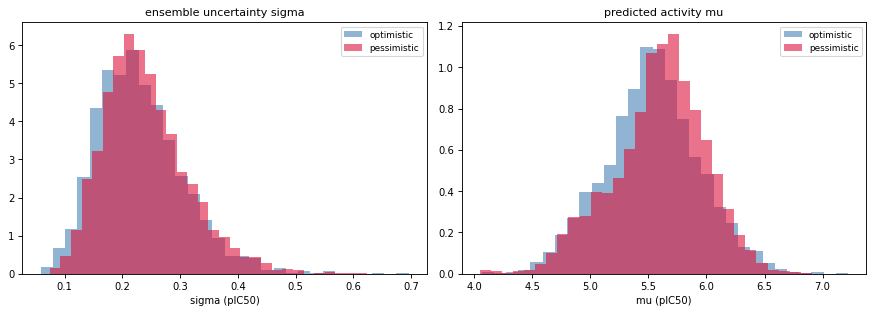

sigma median  -- optimistic 0.221 | pessimistic 0.231
mu median     -- optimistic 5.534 | pessimistic 5.627


In [3]:
def feat(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None: return None
    fp = np.array(AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048))
    d = [Descriptors.MolLogP(m), Descriptors.MolWt(m), Descriptors.NumHDonors(m),
         Descriptors.NumHAcceptors(m), Descriptors.TPSA(m),
         rdMolDescriptors.CalcNumAromaticRings(m), Descriptors.NumRotatableBonds(m)]
    return np.hstack([fp, d]).astype(np.float32)

def mu_sigma(smis):
    mus, sigs = [], []
    for s in set(smis):
        x = feat(s)
        if x is None: continue
        p = np.array([md.predict(x.reshape(1, -1))[0] for md in ens])
        mus.append(p.mean()); sigs.append(p.std())
    return np.array(mus), np.array(sigs)

def late_smiles(d):
    d = d.copy(); d["step"] = np.arange(len(d)) // BATCH
    cut = d["step"].max() * 0.75
    return d[d["step"] >= cut]["SMILES"].tolist()

mu_p, sig_p = mu_sigma(late_smiles(df))                      
dfb = pd.read_csv(f"{RUNDIR}/egfr_multifitness_1.csv")
mu_o, sig_o = mu_sigma(late_smiles(dfb))                     
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(sig_o, bins=30, alpha=0.6, density=True, color="steelblue", label="optimistic")
ax[0].hist(sig_p, bins=30, alpha=0.6, density=True, color="crimson", label="pessimistic")
ax[0].set_title("ensemble uncertainty sigma"); ax[0].set_xlabel("sigma (pIC50)"); ax[0].legend()
ax[1].hist(mu_o, bins=30, alpha=0.6, density=True, color="steelblue", label="optimistic")
ax[1].hist(mu_p, bins=30, alpha=0.6, density=True, color="crimson", label="pessimistic")
ax[1].set_title("predicted activity mu"); ax[1].set_xlabel("mu (pIC50)"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"sigma median  -- optimistic {np.median(sig_o):.3f} | pessimistic {np.median(sig_p):.3f}")
print(f"mu median     -- optimistic {np.median(mu_o):.3f} | pessimistic {np.median(mu_p):.3f}")

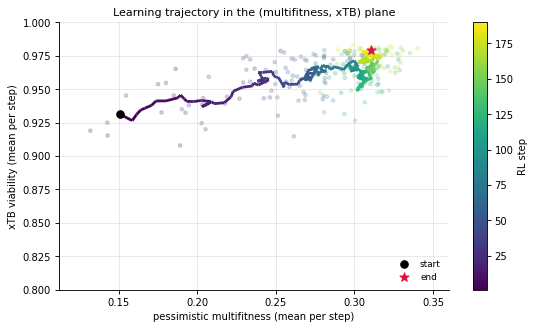

In [4]:
from matplotlib.collections import LineCollection

per_step = df.groupby(step_col)[[mf_col, xtb_col]].mean()
x, y = per_step[mf_col].values, per_step[xtb_col].values
steps = per_step.index.values

# smooth path (rolling mean over steps) to remove per-batch jitter
xs = pd.Series(x).rolling(8, center=True, min_periods=1).mean().values
ys = pd.Series(y).rolling(8, center=True, min_periods=1).mean().values

pts = np.array([xs, ys]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap="viridis", linewidth=2.5)
lc.set_array(steps)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(x, y, c=steps, cmap="viridis", s=10, alpha=0.2, zorder=1)   # faint raw points
ax.add_collection(lc)                                                  # smooth gradient path
ax.scatter(xs[0],  ys[0],  color="black",   s=45, zorder=3, label="start")
ax.scatter(xs[-1], ys[-1], color="crimson", s=70, marker="*", zorder=3, label="end")

ax.set_xlim(x.min() - 0.02, x.max() + 0.02)
ax.set_ylim(0.80, 1.0)                    # zoom on the data band (full scale is 0-1)
ax.set_xlabel("pessimistic multifitness (mean per step)")
ax.set_ylabel("xTB viability (mean per step)")
ax.set_title("Learning trajectory in the (multifitness, xTB) plane")
ax.grid(alpha=0.3)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.colorbar(lc, ax=ax, label="RL step")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout(); plt.show()

## Discussion

Two of the reward terms do not bind. The xTB guardrail never fires, because molecules drawn from the PubChem prior are already electronically stable, so the term sits near its ceiling throughout. Pessimism does not lower uncertainty either, which is the more surprising result, since the reward explicitly penalizes σ. The cause is structural. At λ = 2 the additive penalty λσ is small next to the multiplicative product of four desirabilities, so it barely changes the ranking of candidates. The σ landscape is also nearly flat across drug-like space, so even a stronger penalty would find no low-uncertainty region to move toward.

This is a null result and should be read as one. It does not show that pessimism is useless. It shows that pessimism, embedded in this multiplicative reward at this λ and on this chemical space, has no measurable effect. One limitation is that the comparison here rests on a single run per condition. The multi-seed replication and the controlled, one-term-at-a-time ablation are deferred to the next notebook, which is the proper test of the mechanism.

## Conclusion

This notebook combines the pessimistic multifitness and the xTB viability guardrail into a single reward and evaluates the outcome honestly. The agent optimizes the reward, but neither new term changes the molecules it generates: the guardrail is non-binding on drug-like space, and pessimism at λ = 2 does not reduce uncertainty. Rather than discard the run, its null result motivates the systematic leave-one-out ablation and the shared scoring module that follow.